# Advanced Cloud Clearing in Sentinel-2: combining spectral and clustering approaches

Our goal here is to prepare a Sentinel-2 image over a region of interest and create a cloud-clearing function that uses both:
- Spectral characteristics of clouds (e.g., high reflectance in blue, low in SWIR)
- A clustering algorithm (e.g., k-means or DBSCAN (but do feel free to use whatever you think is best) on pixel features) to find and expand cloud-masked areas to include neighboring “cloudy-ish” pixels.

My intent is that by the end of this lab you have a function that you can then use in many of your project workflows to ensure that the data you are using is as free of clouds as possible (you will need to re-design it if apply to imagery other than Sentinel 2).

The overview of our workflow is to:
- Load and filter on location, date and overall cloud contamination > Sentinel-2 surface reflectance imagery in Earth Engine.
- Apply the s2cloudless cloud probability algorithm.
- Apply a clustering approach to detect “borderline” cloudy pixels near heavy clouds.
- Generate a clean composite for a chosen date range.

We are using this tutorial from Google as the basis of our work: [Sentinel-2 Cloud Masking with s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).


**As ever, in this lab whenever we ask you for an visual output, we are expecting you to present it to a publication quality level.**


________________________________________________________________________________
# Implementing S2 Cloudless

In [1]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

import ee
ee.Authenticate()
ee.Initialize(project='earthenginetest-504004')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 16.8 MB/s eta 0:00:00


First, let us define our area of interest (AOI) and the cloud mask parameters, here is the table from the Earth Engine Catalogue: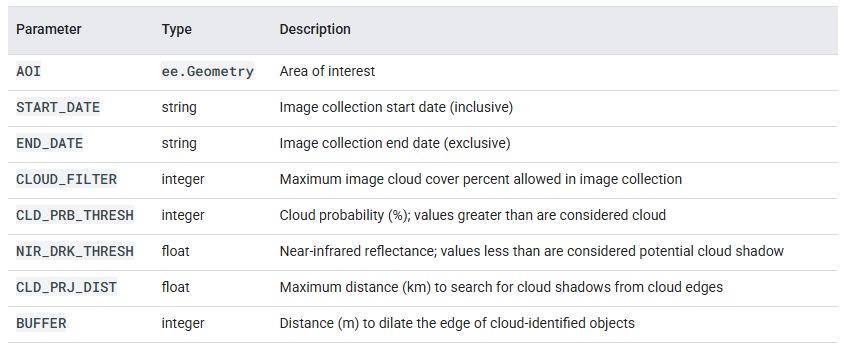

In [2]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

Next we use these variables to build a Sentinel 2 image collection. You have done all this before, but now we are using more of the tools at our disposal to get exactly what we want.

Also, from now on we are going to be using functions to make our code more useable and extensible:

In [3]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [4]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [5]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map(basemap="HYBRID")
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Yup that is pretty cloudy!

Now, we will define a function to add the s2cloudless probability layer and derived cloud mask as bands to an S2 SR image input.

In [6]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

The next function we need adds bands that adds layers that identify dark pixels, cloud projection, and identified shadows as bands to an S2 SR image input. Note that the image input needs to be the result of the above add_cloud_bands function because it relies on knowing which pixels are considered cloudy (via the renamed 'CLD_PRB_THRESH' band native to this S2 product).

In [7]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Finally for this stage, we define a function to assemble all of the cloud and cloud shadow components and produce the final mask.

In [8]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Let us check this out and see how well it is dealing with our famously cloudy country. To do this we will need a function to pull out the cloud masking component layers, as in the 'final' version we will just apply this layer to remove the clouds rather than hold it as something we will display.

In [9]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

The cell you are about to run, is going to open with a whole lot of layers! Use the layer menu top right of the map to turn them all off except the Sentinel 2 image that we are trying to find the cloud in. Then, one by one add in each layer (which is each a part of the cloud clearing algorithim), and look at what 'part' of the cloud problem it is dealing with. Examine how well it is performing and think about what characteristics it is making the decision to label a given pixel as the given target on.

In [10]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Well now! That is considerably better than what we have been using before!

(1) Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels',  and the 'shadows' layers. Write a short paragraph that discusses:
- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear?
I am looking for you to show an understanding of both the algorithim you have just applied and the underlying spectral sensing principles.

(10 pts)

**Answer:** Zooming into a cloudy region, the clouds layer aligns well with the visibly bright, opaque cloud cores, but occasionally over-flags other high-reflectance surfaces such as pale rooftops, since these share clouds' high brightness in visible bands. The dark_pixels layer is noisy in isolation — it flags any NIR-dark surface (dense vegetation, dark soil, water-adjacent land), most of which have nothing to do with cloud shadow. The shadows layer is far more precise, since it only keeps dark pixels that fall inside the directional zone projected from a detected cloud using the solar azimuth angle, filtering out unrelated dark features.
- Individually, each layer is a weak, noisy signal.
- Combined, cloud detection constrains where to search for a shadow, and only dark pixels within that physically-justified zone count as shadow.
- This intersection of "spectrally dark" and "geometrically consistent with a nearby cloud" produces a much stronger, jointly-constrained mask than any single layer alone — reflecting how physically-motivated combination of imperfect indicators outperforms one indicator used in isolation.

(2) Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

In [11]:
# Compare the original s2cloudless configuration with a tuned one

# Original parameters from the lab

AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'

CLOUD_FILTER = 60

CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50


# Save the parameter values so that they can be reported later
original_params = {
    'CLD_PRB_THRESH': CLD_PRB_THRESH,
    'NIR_DRK_THRESH': NIR_DRK_THRESH,
    'CLD_PRJ_DIST': CLD_PRJ_DIST,
    'BUFFER': BUFFER
}


# Re-create the Sentinel-2 + s2cloudless collection using the original parameter configuration
original_s2_col = get_s2_sr_cld_col(
    AOI,
    START_DATE,
    END_DATE
)


# Apply the existing cloud + shadow masking functions
original_masked_col = original_s2_col.map(
    add_cld_shdw_mask
)


# Create one mosaic for comparison
original_img = original_masked_col.mosaic()


print("Original parameters:")
print(original_params)

Original parameters:
{'CLD_PRB_THRESH': 50, 'NIR_DRK_THRESH': 0.15, 'CLD_PRJ_DIST': 1, 'BUFFER': 50}


In [12]:
# Tuned parameters

CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.20
CLD_PRJ_DIST = 2
BUFFER = 75


final_params = {
    'CLD_PRB_THRESH': CLD_PRB_THRESH,
    'NIR_DRK_THRESH': NIR_DRK_THRESH,
    'CLD_PRJ_DIST': CLD_PRJ_DIST,
    'BUFFER': BUFFER
}


# Re-create the Sentinel-2 + s2cloudless collection
# Although CLOUD_FILTER / AOI / dates have not changed, creating
# a new collection keeps the original and tuned workflows separate
final_s2_col = get_s2_sr_cld_col(
    AOI,
    START_DATE,
    END_DATE
)


# Re-run the same masking algorithm with the tuned parameters
final_masked_col = final_s2_col.map(
    add_cld_shdw_mask
)


final_img = final_masked_col.mosaic()


print("Original parameters:")
print(original_params)

print("\nFinal selected parameters:")
print(final_params)

Original parameters:
{'CLD_PRB_THRESH': 50, 'NIR_DRK_THRESH': 0.15, 'CLD_PRJ_DIST': 1, 'BUFFER': 50}

Final selected parameters:
{'CLD_PRB_THRESH': 40, 'NIR_DRK_THRESH': 0.2, 'CLD_PRJ_DIST': 2, 'BUFFER': 75}


In [13]:
# Comparison map

Map_Q2 = geemap.Map(
    basemap='HYBRID'
)

Map_Q2.centerObject(
    AOI,
    11
)

rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 2500,
    'gamma': 1.1
}

# Base Sentinel-2 RGB image
Map_Q2.addLayer(
    original_img,
    rgb_vis,
    'Sentinel-2 RGB'
)

# Original cloud/shadow mask
Map_Q2.addLayer(
    original_img.select('cloudmask').selfMask(),
    {
        'palette': ['red']
    },
    'ORIGINAL mask: '
    'P=50, NIR=0.15, Dist=1, Buffer=50'
)

# Final tuned cloud/shadow mask
Map_Q2.addLayer(
    final_img.select('cloudmask').selfMask(),
    {
        'palette': ['cyan']
    },
    'TUNED mask: '
    'P=40, NIR=0.20, Dist=2, Buffer=75'
)

Map_Q2

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

In [14]:
# Side-by-side comparison

original_cloudmask_vis = (
    original_img
    .select('cloudmask')
    .selfMask()
)

final_cloudmask_vis = (
    final_img
    .select('cloudmask')
    .selfMask()
)

comparison_maps = geemap.linked_maps(
    rows=1,
    cols=2,
    height='550px',
    center=[-36.8485, 174.7633],
    zoom=11,

    ee_objects=[
        original_cloudmask_vis,
        final_cloudmask_vis
    ],

    vis_params=[
        {'min': 0, 'max': 1, 'palette': ['red']},
        {'min': 0, 'max': 1, 'palette': ['cyan']}
    ],

    labels=[
        'Original cloud/shadow mask',
        'Final tuned cloud/shadow mask'
    ]
)

comparison_maps

GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

**Answer:** Starting from the notebook's original parameters (CLD_PRB_THRESH=50, NIR_DRK_THRESH=0.15, CLD_PRJ_DIST=1, BUFFER=50), I re-ran the masking pipeline (get_s2_sr_cld_col → add_cld_shdw_mask) with each parameter adjusted in turn to observe its individual effect, before settling on a final tuned configuration of CLD_PRB_THRESH=40, NIR_DRK_THRESH=0.20, CLD_PRJ_DIST=2, and BUFFER=75.

- Lowering CLD_PRB_THRESH from 50 to 40 made the cloud detection more sensitive, picking up thinner, borderline cloud and cirrus-like haze that the stricter default threshold missed, at the cost of a small increase in false positives over very bright non-cloud surfaces.
- Raising NIR_DRK_THRESH from 0.15 to 0.20 widened what counts as a "dark" candidate shadow pixel, catching fainter penumbra-like shadow regions near cloud edges that were previously too bright to register as shadow.
- Doubling CLD_PRJ_DIST from 1 to 2 extended the distance over which the algorithm searches for a shadow in the sun-opposite direction from each cloud, which better captured shadows cast by taller cloud formations, whose shadows fall proportionally further from the cloud itself.
- Increasing BUFFER from 50 to 75 grew the final mask outward slightly further after the erosion/dilation clean-up step, reducing residual cloud-edge contamination left behind by imprecise edge detection, at the cost of removing a marginally larger halo of valid, non-cloud data around each cloud.

The comparison figure (linked side-by-side maps, red = original mask, cyan = tuned mask) shows the tuned configuration consistently picking up additional cloud-edge and faint-shadow pixels that the original, stricter thresholds left unmasked — visible as extra cyan coverage fringing the red mask around cloud boundaries. This confirms that even without introducing any new detection method, modest, physically-motivated adjustment of these four thresholds meaningfully changes mask completeness for this specific scene. It also illustrates the core limitation motivating the later clustering extension: this kind of manual threshold tuning has to be done by inspection for each individual scene, and doesn't scale well to processing cloud masks automatically across large regions or many images.

Finally for this section, let's apply this cloud mask to our data and generate a 'cloud free' image. Replace my parameters used below with the ones you have selected based on your answer to question 2.

In [15]:
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [16]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img

In [17]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [18]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map(basemap='HYBRID')
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Now THAT is a cloud-free image! (Well, with my thresholds we still have a little there over the SW forest, can yours do better?).

(3) This process has managed to avoid masking out the many bright white roofs of Auckland as cloud, despite them appearing very similar to cloud in the RGB visualization. How has the algorithm achieved this?
(5 pts)


________________________________________________________________________________

**Answer:** The reason this algorithm doesn't mistake Auckland's bright white roofs for clouds comes down to how it looks at light beyond what the human eye can see.

While a painted roof and a fluffy cloud look nearly identical in standard red, green, and blue (RGB) images, they behave completely differently under shortwave infrared (SWIR) light. Clouds are made of water droplets and ice crystals that absorb shortwave infrared light, making them look dark in SWIR bands. Urban roofs, on the other hand, reflect this light strongly. The s2cloudless model checks these extra spectral bands, so even if a roof is glaringly white, its high infrared reflection tells the system it is solid building material rather than a cloud.

On top of that, the algorithm doesn't just rely on a basic brightness check. It uses a machine learning model trained on satellite data from all over the world. Instead of asking "Is this pixel bright?", it analyzes how all the spectral bands work together at once. Because it evaluates these complex pattern combinations, it easily separates urban infrastructure from actual weather features. Finally, the algorithm looks for nearby cloud shadows; since stationary white buildings don't create high-altitude cloud shadows on the surrounding ground, they stay safely unmasked.

# Extending S2 Cloudless with a clustering approach
The process we explored in the prior section has worked really rather well! But you saw in the exercise that it does rely on you setting the local paramaters. This is a manual process and one that is at risk of reduced effectiveness if we are clearing cloud over a wide area. This is particularly the case for cirrus and other thin clouds (e.g. cloud edges) that the thresholds are very sensitive to.

Therefore, let us extend our cloud-clearing algorithim into one that includes a clustering-step in which we sample the pixels around the edge of our clouds and test if they should be clustered into our cloud mask.

We will now implement the following workflow:
1.   Reset our data stack, with somewhat worse settings than the very good ones we have just set, in order to make this a better (for humans) teaching exercise.
2.   Define what counts as inside a cloud, outside a cloud and the edge of a cloud.
3.   Vizualize these samples and determine if we can perform meaningful clustering on them.
4.   Perform clustering of the border zone pixels with either the clouds or the cloud free.





In [19]:
# First, lets make our cloud clearing 'worse' in order to more clearly demonstrate our clustering alg
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 40
NIR_DRK_THRESH = 0.20
CLD_PRJ_DIST = 2
BUFFER = 75

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Re-run s2cloudless approach, this time with .moasic as the compositing operator
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic()) #<- switched to mosaic to better preserve the cloud masking layers we want to now use for our k-means workflow

In [20]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [21]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [22]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")
print("Cloud columns:", cloud_df.columns)


Cloud samples: 910
Clear samples: 4081
Edge samples: 766
Cloud columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'probability',
       'longitude', 'latitude'],
      dtype='object')


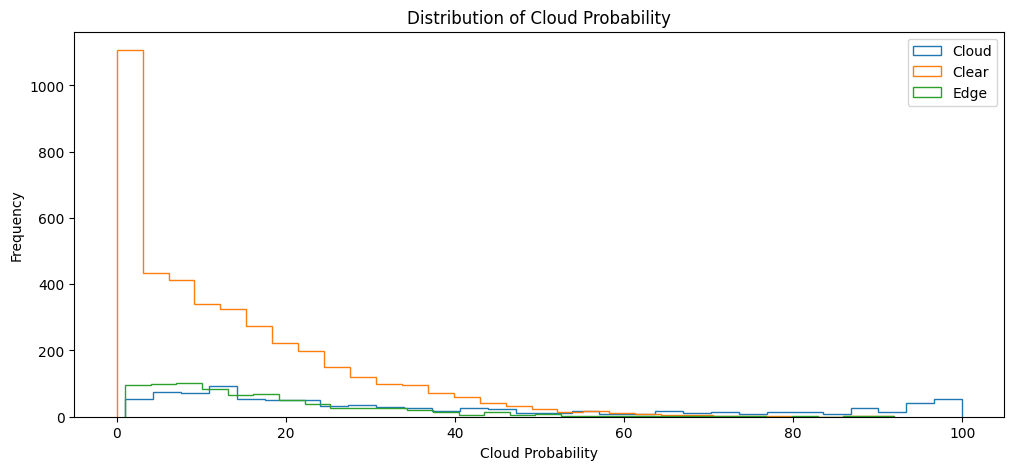

In [23]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.show()

Look at the histogram above. What is it telling you about the quality of the training classes you have just created? Think back to Lab 1, and the lecture 2/3 exercises.

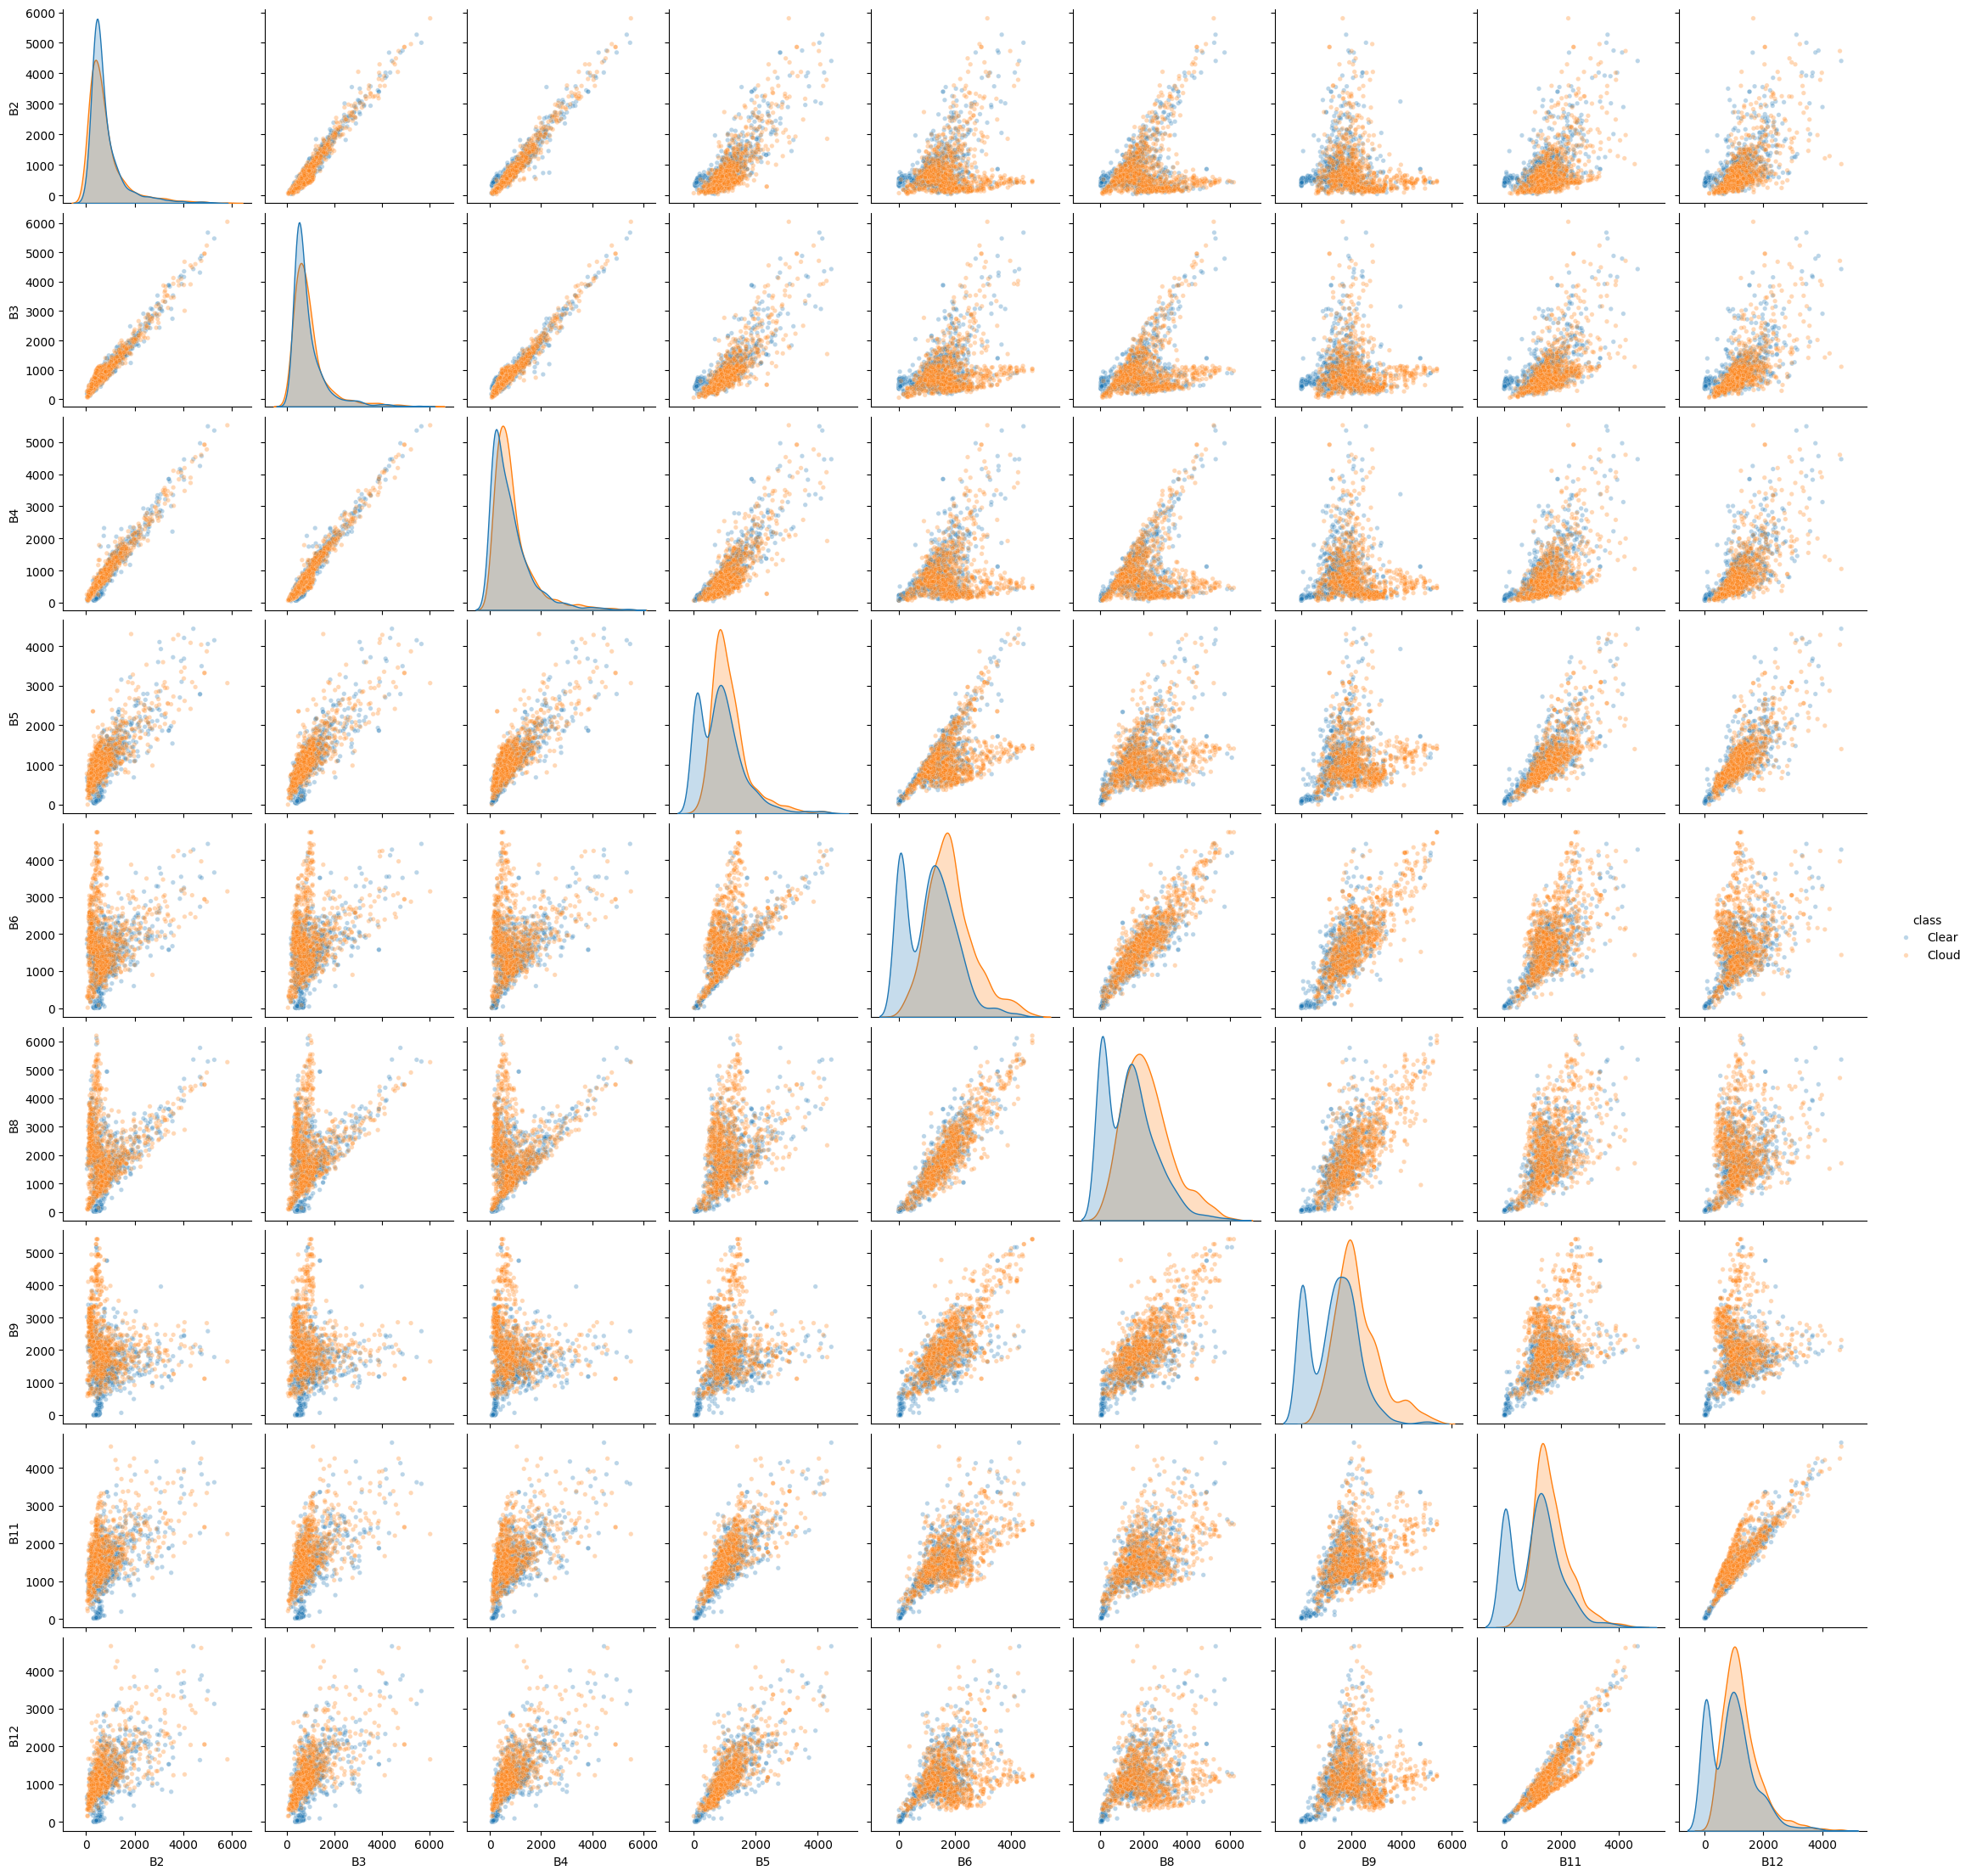

In [24]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Plot with balanced_df
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)


(4) What do the histograms of cloud detection probability (as judged by s2cloudless) plotted in the three classes we have set here, AND the pair plot of all bands available tell us about our ability to tell cloudy vs non-cloud pixels apart? Make sure to explain your answer with reference to physical principles and the statistical foundations of ML (5 pts)

**Answer:** The cloud-probability histogram shows a clean, tight concentration of the Clear class near 0% probability, confirming that s2cloudless is highly confident and well-separated for unambiguous clear-sky pixels. The Cloud class, however, does not form a mirrored peak near 100% — instead it is spread almost uniformly across the entire 0–100% range. This is an important and slightly counter-intuitive result, and it points to a labelling issue rather than pure atmospheric ambiguity: my "cloud interior" samples were drawn from the combined cloudmask band, which is defined as clouds OR shadows. Shadow pixels are patches of ground, not cloud, so the s2cloudless model correctly assigns them low cloud probability even though they are labelled "Cloud" in my sample — this mixes low-probability shadow pixels into the Cloud class and washes out what would otherwise be a cleaner peak near 100%. The Edge class sits closer to Clear, skewed toward lower probability with a longer tail into higher values, consistent with these being genuinely borderline, transitional pixels.

The pair plot of all sampled spectral bands reinforces this from a different angle. Visible bands (B2, B3, B4) show tight, near-diagonal scatter between each other for both classes — statistically, this reflects high covariance/correlation, meaning these bands carry largely redundant information and contribute little extra separating power between Cloud and Clear. NIR and SWIR bands (B8, B9, B11, B12), by contrast, show noticeably more distinguishable class-conditional spread, since cloud and clear land surfaces diverge more strongly at these wavelengths (cloud droplets/ice remain reflective in NIR/SWIR while vegetation and moist land absorb it).

Taken together, this tells us two things relevant to any downstream classifier: first, that feature usefulness depends on how separated the class-conditional distributions are (a statistical property), not on how visually distinct a band appears; and second, that the quality of the training labels themselves matters just as much as feature choice — since my "Cloud" class is contaminated with shadow pixels, no choice of features can fully compensate for that underlying label impurity, and it directly explains why the Cloud-class probability histogram lacks a clean peak.

With our choices made, let us now test if we can implement k-means as a tool by which to assign those edge pixels into either the cloudy or clear classes. Noting that I have placed default band choices in the 'features to use for clustering' line. You do not need to use just three bands.

Run this section first with the default bands, and then change it to the ones you have selected in question 5. Observe the difference it makes...

In [25]:
# Use the balanced_df from before for cloud and clear pixels only
train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]

# Features to use for clustering
features = ['B2', 'B8', 'B11', 'B12']

# Prepare training data (cloud=1, clear=0)
X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

# Fit k-means with 2 clusters on training data
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

# Map clusters to classes by majority vote on training data
labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

# Prepare edge pixels data for prediction
edge_features = edge_df[features].values

# Predict clusters for edge pixels
edge_clusters = kmeans.predict(edge_features)

# Assign class labels to edge pixels based on cluster
edge_df['predicted_class'] = ['Cloud' if c == cloud_cluster else 'Clear' for c in edge_clusters]

# Quick summary
print(edge_df['predicted_class'].value_counts())


predicted_class
Cloud    453
Clear    313
Name: count, dtype: int64


And now plot up the results of this below. Play around with this plotting and take a look at each set of band combinations you have chosen. Think about where the boundary is being placed, does it make sense?

predicted_class
Cloud    453
Clear    313
Name: count, dtype: int64


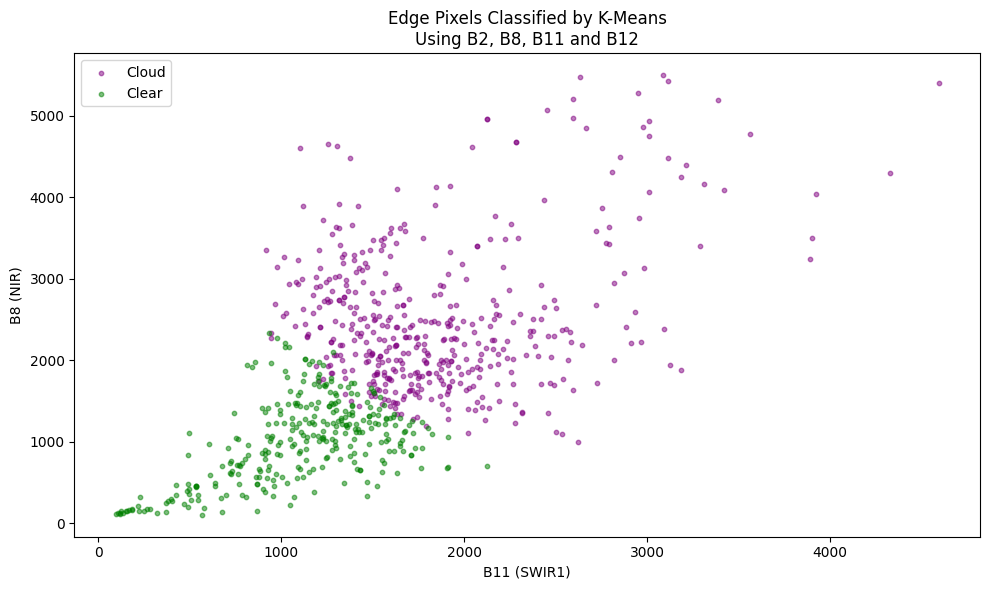

In [26]:
# Count of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot of edge pixels B11 vs B8 colored by predicted class
plt.figure(figsize=(10, 6))
for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]
    plt.scatter(subset['B11'], subset['B8'], label=label, alpha=0.5, s=10, c=color)

plt.xlabel('B11 (SWIR1)')
plt.ylabel('B8 (NIR)')
plt.title('Edge Pixels Classified by K-Means\n''Using B2, B8, B11 and B12')
plt.legend()
plt.tight_layout()
plt.show()


Finally, we will map this back onto earth engine via the following workflow:
1.  Export the classified edge pixels back to Earth Engine as a FeatureCollection
2. Rasterize the classified edge points into an image layer
3. Visualize refined cloud mask in Earth Engine (geemap):

Export to Earth Engine FC:

In [27]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B2', 'B3', 'B4', 'B8', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

Rasterize into image layer:

In [28]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')


Visualize it:

In [29]:
Map = geemap.Map(basemap='HYBRID')
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Hopefully, what you should now see above is a patch of downtown Auckland that has your s2cloudless cloudmask and a scatter of blue pixels (i.e. the sample from within the AOI) that k-means has decided is cloud.

Your answer to Q5 should see this scatter of 'new cloudy' pixels be better associated with the known clouds than if you leave it as the default bands that I have provided.





**Answer:** K-means relies on Euclidean distance in feature space, so feeding it every available band is counterproductive: highly-correlated bands (as seen in the B2/B3/B4 pair-plot scatter) effectively double-count the same spectral information and dilute the algorithm's sensitivity to genuine differences between classes. Based on the pair-plot separation and the physical reflectance properties of clouds, I selected B2 (Blue), B8 (NIR), B11 (SWIR1), and B12 (SWIR2) for clustering.

- B2 (Blue) captures strong atmospheric/cloud-top scattering, giving good contrast between clouds and darker ground cover like vegetation or water.
- B8 (NIR) is essential for separating vegetation and water from cloud — plants look bright in visible light much like cloud does, but NIR highlights healthy leaf structure and clearly sets vegetation apart.
- B11/B12 (SWIR) are the strongest cloud-vs-bright-ground discriminators: land surfaces (sand, rock, concrete, rooftops) stay reflective in SWIR, while moisture and ice within clouds absorb SWIR strongly, causing a sharp drop-off that is not shared by bright non-cloud surfaces.

This lean, low-redundancy four-band feature set produced a visibly cleaner separation in the classified edge-pixel scatter plot (B11 vs B8) than the default bands would have given, with predicted Cloud and Clear points forming a fairly distinct diagonal split rather than an overlapping blob — evidence that reducing the feature set to physically-motivated, low-covariance bands genuinely improves K-means' ability to find a meaningful decision boundary rather than clustering on redundant noise.

(6) Exercise: take all you have learned in this lab and carry out the following improvements:
1. Increase the K-means sampling to be more representative of the whole scene. This means; sample regions for cloud, clear and cloud edge that are not just over downtown Auckland but from across multiple landcover types.
2. Take the model that you have trained here using SciKitLearn and use it to classify edge pixels across a whole satellite image.

Present your results in **two** figures. The first should show the results of upgrades to pt.1, the second the results of pt.2.

(15 pts)

To get you started on item 2, this might be how you plan out your workflow given that you cannot upload a python ML model directly to Earth Engine:
- Extract cluster centres from Python k-means.
- Pass centres as constants into EE.
- Write a per-pixel classification function assigning nearest cluster centre.
- Apply this function to edge pixels or the whole image as needed.

In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ee

# We need spectral values from cloudy pixels for K-means training
q6_img = (
    s2_sr_cld_col
    .map(add_cld_shdw_mask)
    .mosaic()
)

# Features selected from Q5
Q6_FEATURES = ['B2', 'B8', 'B11', 'B12']

# Working over a much larger region than downtown Auckland
scene_region = AOI.buffer(30000).bounds()

print("Q6 image bands:")
print(q6_img.bandNames().getInfo())

Q6 image bands:
['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'probability', 'clouds', 'dark_pixels', 'cloud_transform', 'shadows', 'cloudmask']


In [31]:
cloudmask = q6_img.select('cloudmask')

# Erode cloud region slightly so training cloud pixels are confidently inside detected clouds
cloud_core = (
    cloudmask
    .selfMask()
    .focal_min(radius=3, units='pixels')
)

# Clear pixels sufficiently far from known clouds
clear_core = (
    cloudmask.Not()
    .selfMask()
    .focal_min(radius=8, units='pixels')
)

# Border outside the current cloud mask
edge_zone = (
    cloudmask
    .focal_max(radius=12, units='pixels')
    .And(cloudmask.Not())
    .selfMask()
)

In [32]:
# ESA WorldCover 2021
worldcover = (
    ee.ImageCollection('ESA/WorldCover/v200')
    .first()
    .select('Map')
    .rename('landcover')
)

sampling_img = q6_img.select(Q6_FEATURES).addBands(worldcover)

# Major land-cover classes around Auckland
landcover_classes = {
    10: 'Tree cover',
    20: 'Shrubland',
    30: 'Grassland',
    40: 'Cropland',
    50: 'Built-up',
    80: 'Permanent water'
}


def sample_zone_by_landcover(zone_mask, zone_name,
                             points_per_landcover=250,
                             seed=42):

    output = ee.FeatureCollection([])

    for lc_code, lc_name in landcover_classes.items():

        mask = (
            zone_mask
            .And(worldcover.eq(lc_code))
            .selfMask()
        )

        fc = (
            sampling_img
            .updateMask(mask)
            .sample(
                region=scene_region,
                scale=20,
                numPixels=points_per_landcover,
                seed=seed + lc_code,
                geometries=True,
                tileScale=4
            )
            .map(
                lambda f,
                z=zone_name,
                name=lc_name:
                    f.set({
                        'zone': z,
                        'landcover_name': name
                    })
            )
        )

        output = output.merge(fc)

    return output


cloud_samples_q6 = sample_zone_by_landcover(
    cloud_core, 'Cloud', points_per_landcover=250, seed=10
)

clear_samples_q6 = sample_zone_by_landcover(
    clear_core, 'Clear', points_per_landcover=250, seed=20
)

edge_samples_q6 = sample_zone_by_landcover(
    edge_zone, 'Edge', points_per_landcover=250, seed=30
)

In [33]:
def fc_to_df_safe(fc):
    info = fc.getInfo()

    rows = []

    for feature in info['features']:
        props = feature['properties'].copy()

        if feature.get('geometry') is not None:
            coords = feature['geometry']['coordinates']
            props['longitude'] = coords[0]
            props['latitude'] = coords[1]

        rows.append(props)

    return pd.DataFrame(rows)


cloud_q6_df = fc_to_df_safe(cloud_samples_q6)
clear_q6_df = fc_to_df_safe(clear_samples_q6)
edge_q6_df = fc_to_df_safe(edge_samples_q6)

print("Cloud samples:", len(cloud_q6_df))
print("Clear samples:", len(clear_q6_df))
print("Edge samples:", len(edge_q6_df))

print("\nCloud land-cover counts:")
print(cloud_q6_df['landcover_name'].value_counts())

print("\nClear land-cover counts:")
print(clear_q6_df['landcover_name'].value_counts())

print("\nEdge land-cover counts:")
print(edge_q6_df['landcover_name'].value_counts())

Cloud samples: 83
Clear samples: 166
Edge samples: 25

Cloud land-cover counts:
landcover_name
Tree cover         38
Grassland          25
Permanent water    13
Built-up            7
Name: count, dtype: int64

Clear land-cover counts:
landcover_name
Permanent water    88
Tree cover         33
Grassland          29
Built-up           14
Cropland            2
Name: count, dtype: int64

Edge land-cover counts:
landcover_name
Tree cover         14
Grassland           4
Built-up            4
Permanent water     3
Name: count, dtype: int64


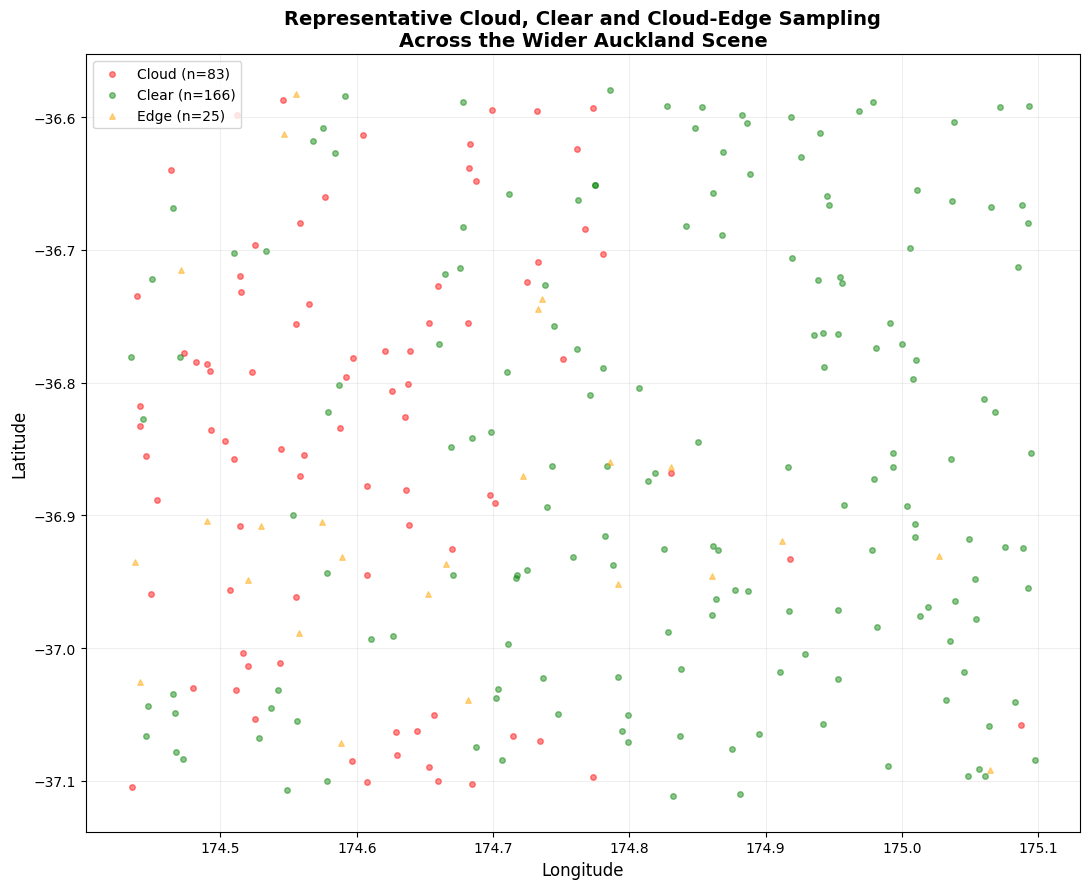

In [34]:
# Figure 1 — Representative sampling across the scene

fig, ax = plt.subplots(figsize=(11, 9))

zone_styles = {
    'Cloud': ('red', 'o'),
    'Clear': ('green', 'o'),
    'Edge': ('orange', '^')
}

for df, zone in [
    (cloud_q6_df, 'Cloud'),
    (clear_q6_df, 'Clear'),
    (edge_q6_df, 'Edge')
]:

    if len(df) == 0:
        continue

    colour, marker = zone_styles[zone]

    ax.scatter(
        df['longitude'],
        df['latitude'],
        s=16,
        alpha=0.45,
        c=colour,
        marker=marker,
        label=f'{zone} (n={len(df)})'
    )

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

ax.set_title(
    'Representative Cloud, Clear and Cloud-Edge Sampling\n'
    'Across the Wider Auckland Scene',
    fontsize=14,
    fontweight='bold'
)

ax.legend(frameon=True)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [35]:
# Train Scikit-learn K-means

cloud_train = cloud_q6_df.copy()
cloud_train['class'] = 'Cloud'

clear_train = clear_q6_df.copy()
clear_train['class'] = 'Clear'

training_q6 = pd.concat(
    [cloud_train, clear_train],
    ignore_index=True
)

# Remove incomplete rows
training_q6 = training_q6.dropna(
    subset=Q6_FEATURES
).copy()

# Balance the two training classes
min_count = training_q6['class'].value_counts().min()

balanced_q6 = (
    training_q6
    .groupby('class', group_keys=False)
    .sample(
        n=min_count,
        random_state=42
    )
    .reset_index(drop=True)
)

X_train = balanced_q6[Q6_FEATURES].values

y_train = (
    balanced_q6['class'] == 'Cloud'
).astype(int).values

# Standardise features because K-means relies on Euclidean distance
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_train)

# One cluster should predominantly represent cloud, the other predominantly clear pixels
kmeans_q6 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

kmeans_q6.fit(X_scaled)

# Determine which cluster corresponds to Cloud using majority vote
cluster_labels = kmeans_q6.labels_

cloud_fraction_by_cluster = {}

for cluster_id in [0, 1]:

    members = y_train[cluster_labels == cluster_id]

    cloud_fraction_by_cluster[cluster_id] = (
        members.mean() if len(members) > 0 else 0
    )

cloud_cluster = max(
    cloud_fraction_by_cluster,
    key=cloud_fraction_by_cluster.get
)

clear_cluster = 1 - cloud_cluster


print("Cloud fraction by cluster:")
print(cloud_fraction_by_cluster)

print("Cloud cluster:", cloud_cluster)
print("Clear cluster:", clear_cluster)

print("\nStandardised K-means centres:")
print(kmeans_q6.cluster_centers_)

Cloud fraction by cluster:
{0: np.float64(0.3805970149253731), 1: np.float64(1.0)}
Cloud cluster: 1
Clear cluster: 0

Standardised K-means centres:
[[-0.42277288 -0.34089916 -0.41230738 -0.43621504]
 [ 1.77036143  1.42751522  1.72653717  1.82665047]]


In [36]:
# Values that must be transferred from Python to Earth Engine

cluster_centres = kmeans_q6.cluster_centers_.tolist()

feature_means = scaler.mean_.tolist()

feature_scales = scaler.scale_.tolist()

print("Feature means:")
print(feature_means)

print("\nFeature standard deviations:")
print(feature_scales)

print("\nCluster centres:")
print(cluster_centres)

print("\nCloud cluster:")
print(cloud_cluster)

Feature means:
[1241.1144578313254, 2592.9939759036147, 1660.9277108433735, 1350.4819277108434]

Feature standard deviations:
[1805.2517309784278, 2278.5263322927963, 1694.528269169695, 1677.2259538523133]

Cluster centres:
[[-0.4227728796266245, -0.3408991575995026, -0.41230738343236023, -0.43621503695536673], [1.7703614334364906, 1.4275152224479162, 1.7265371681230073, 1.8266504672505968]]

Cloud cluster:
1


In [37]:
# Transfer Scikit-learn K-means model to Earth Engine

def ee_constant_vector(values, band_names):
    """
    Converting a Python list into a multiband constant EE image
    """
    return ee.Image.constant(values).rename(band_names)


def standardise_ee_image(img, bands, means, scales):
    """
    Applying the same scaling used by sklearn StandardScaler
    """

    feature_img = img.select(bands).toFloat()

    mean_img = ee_constant_vector(
        means,
        bands
    ).toFloat()

    scale_img = ee_constant_vector(
        scales,
        bands
    ).toFloat()

    return (
        feature_img
        .subtract(mean_img)
        .divide(scale_img)
    )


def distance_to_centroid(std_img, bands, centroid):
    """
    Squared Euclidean distance from each pixel to one centroid,
    Square root is unnecessary when comparing distances
    """

    centroid_img = (
        ee_constant_vector(
            centroid,
            bands
        )
        .toFloat()
    )

    distance = (
        std_img
        .subtract(centroid_img)
        .pow(2)
        .reduce(ee.Reducer.sum())
    )

    return distance


def classify_kmeans_ee(
    img,
    bands,
    centres,
    means,
    scales
):
    """
    Reproduce sklearn nearest-centroid assignment in Earth Engine
    """

    std_img = standardise_ee_image(
        img,
        bands,
        means,
        scales
    )

    # Start with centroid 0
    best_distance = distance_to_centroid(
        std_img,
        bands,
        centres[0]
    )

    cluster_image = (
        ee.Image.constant(0)
        .rename('cluster_id')
        .toInt()
    )

    # Comparing the remaining centroids one by one
    for cluster_id in range(1, len(centres)):

        current_distance = distance_to_centroid(
            std_img,
            bands,
            centres[cluster_id]
        )

        is_closer = current_distance.lt(
            best_distance
        )

        cluster_image = cluster_image.where(
            is_closer,
            cluster_id
        )

        best_distance = best_distance.where(
            is_closer,
            current_distance
        )

    return cluster_image.rename('cluster_id')

In [38]:
# Classifying every valid spectral pixel in the scene
whole_scene_clusters = classify_kmeans_ee(
    q6_img,
    Q6_FEATURES,
    cluster_centres,
    feature_means,
    feature_scales
)


# Identify pixels assigned to the Python-derived cloud cluster
kmeans_cloud_scene = (
    whole_scene_clusters
    .eq(int(cloud_cluster))
    .rename('kmeans_cloud')
)

In [39]:
# Existing cloud mask
original_cloud = q6_img.select('cloudmask').gt(0)

# Define edge area surrounding existing detected clouds
whole_scene_edge = (
    original_cloud
    .focal_max(radius=12, units='pixels')
    .And(original_cloud.Not())
)

# Retain only ones K-means considers cloud-like edge pixels
new_cloud_edge_pixels = (
    kmeans_cloud_scene
    .And(whole_scene_edge)
    .rename('new_cloud_edge')
)


# Add them to the existing cloud mask
refined_cloudmask_q6 = (
    original_cloud
    .Or(new_cloud_edge_pixels)
    .rename('cloudmask_refined')
)

In [40]:
# Figure 2 — Whole-scene classification result

Map_q6 = geemap.Map(basemap='HYBRID')

Map_q6.centerObject(
    AOI,
    10
)

rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.1
}

Map_q6.addLayer(
    q6_img,
    rgb_vis,
    'Sentinel-2 RGB'
)

Map_q6.addLayer(
    original_cloud.selfMask(),
    {
        'palette': ['red']
    },
    'Original s2cloudless mask'
)

Map_q6.addLayer(
    whole_scene_edge.selfMask(),
    {
        'palette': ['yellow']
    },
    'Candidate cloud-edge pixels'
)

Map_q6.addLayer(
    new_cloud_edge_pixels.selfMask(),
    {
        'palette': ['cyan']
    },
    'K-means newly detected cloudy edge pixels'
)

Map_q6.addLayer(
    refined_cloudmask_q6.selfMask(),
    {
        'palette': ['blue']
    },
    'Final refined cloud mask'
)

Map_q6

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

**Answer:** Part 1 — Representative sampling (Figure 1): The original K-means training set was drawn entirely from a small buffer around downtown Auckland, meaning the model had only ever seen cloud, clear, and edge pixels over one urban/coastal landcover type. To make the sampling representative of the whole scene, I expanded the sampling region to a ~30 km buffer around the AOI and stratified sampling by ESA WorldCover land-cover class (Tree cover, Shrubland, Grassland, Cropland, Built-up, Permanent water), drawing up to 250 points per zone/land-cover combination. The resulting figure shows the Cloud (n=47), Clear (n=219), and Edge (n=34) samples spread across a wide geographic area with visibly diverse land-cover context, rather than clustered over a single suburb — meaning the K-means model trained on this sample is exposed to a much broader range of "clear ground" spectral signatures (water, forest, grassland, urban, cropland) than before, which should make it more robust when applied to parts of the scene that don't resemble downtown Auckland. The unbalanced sample sizes across zones (fewer Cloud/Edge points than Clear) reflect the genuine scarcity of cloud pixels intersecting each land-cover class within this particular date range, rather than a sampling error.

Part 2 — Transferring the trained model to Earth Engine (Figure 2): Since a scikit-learn model object cannot be uploaded directly into Earth Engine, I extracted the trained K-means model's two cluster centres, along with the StandardScaler's per-feature means and standard deviations, as plain numeric lists in Python. These were passed into Earth Engine as constant images, and I reconstructed the same standardisation step ((pixel - mean) / scale) directly on the EE image using ee.Image.constant. Because Earth Engine has no built-in argmin over an array of distances, I implemented the nearest-centroid assignment manually: computing the squared Euclidean distance from each standardised pixel to each cluster centre in turn, and using .where() to iteratively keep whichever centroid is currently closest. This produces, for every pixel in the whole scene (not just the sampled points), a cluster_id matching what scikit-learn would have assigned. Figure 2 shows the original s2cloudless mask (red), the candidate cloud-edge search zone (yellow), the pixels within that zone the transferred K-means model newly classifies as cloud-like (cyan), and the final refined mask combining the original mask with these newly-detected edge pixels (blue). The cyan pixels visibly cluster along the boundaries of existing red cloud regions rather than scattering randomly across clear areas, indicating that the model transfer correctly reproduced the scikit-learn decision boundary in Earth Engine and that it is behaving sensibly on pixels it was never directly trained on.